# CME Futures: Feasibility Analysis

`config/setup.yaml` declares a cross-sectional futures strategy: which products trade, how
often positions change, what crossing costs, how the sample is split. This notebook asks
whether the data supports it, and fits nothing.

## Learning objectives

- Count the universe on the session the strategy acts on, price the spread from the
  contract's own tick, and read clearance off an exceedance curve scaled by that spread
- Measure how long the carry a strategy reads stays put, and confirm the declared folds
  fit the sample without touching the holdout

## Book reference

Chapter 6, Sections 6.2-6.6. Reads CME settlements and `config/setup.yaml`, never writes.

In [1]:
"""CME Futures Case Study - Feasibility Analysis."""

import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from pandas.tseries.holiday import GoodFriday

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_cme_futures
from utils.config import REPO_ROOT
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
START_DATE = "2011-01-01"
END_DATE = "2025-12-31"

## Configuration

Every knob is read from `setup.yaml`, and Section B computes on the development window
alone, so nothing the holdout contains can shape a choice made here.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
DECLARED_PRODUCTS = sorted(p for g in SETUP["universe"]["product_groups"].values() for p in g)
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
SPREAD_TICKS = SETUP["costs"]["spread_ticks"]
ILLIQUID = set(SETUP["costs"]["illiquid_products"])
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]
HORIZONS = sorted(int(re.search(r"(\d+)d$", name).group(1)) for name in LABELS)
PRIMARY_HORIZON = int(re.search(r"(\d+)d$", PRIMARY_LABEL).group(1))

print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(
    f"{len(DECLARED_PRODUCTS)} products, floor {BREADTH_FLOOR} | horizons {HORIZONS} sessions, "
    f"primary {PRIMARY_LABEL} at {PRIMARY_HORIZON}"
)

Development 2011-01-01 to 2024-01-01 | sealed holdout to 2025-12-31
30 products, floor 20 | horizons [5, 21] sessions, primary fwd_ret_5d at 5


## A. Orientation

CME futures give leveraged exposure across equity indices, rates, energy, metals,
currencies, agriculture and livestock through one order type and one clearing house. A
front-month position earns the spot move plus the roll yield the term structure implies,
so ranking products against each other trades a difference in carry as much as one in
direction. Three questions decide whether that is worth building here: does the universe
exist on every decision date, is a typical move large next to the cost of capturing it,
and are there enough decision dates for a walk-forward that never reads the holdout?

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe

The loader returns one row per product, tenor and session; `tenor == 0` is the front month.
`raw_close` is the printed settlement and `adj_close` is back-adjusted, so its differences
are moves not rolls. Neither is a safe denominator unguarded.

In [4]:
futures = load_cme_futures(start_date=START_DATE, end_date=END_DATE)
front = (
    futures.filter(pl.col("tenor") == 0)
    .select(["product", "session_date", "raw_close", "adj_close"])
    .sort(["product", "session_date"])
)
research = front.filter(pl.col("session_date") < pl.lit(HOLDOUT_START).str.to_date())

missing = sorted(set(DECLARED_PRODUCTS) - set(research["product"].unique().to_list()))
assert not missing, f"declared in setup.yaml but absent from the data: {missing}"
print(
    f"{research['product'].n_unique()} products, {len(research):,} settlements, "
    f"{research['session_date'].min()} to {research['session_date'].max()}"
)

30 products, 98,116 settlements, 2011-01-03 to 2023-12-29


### B.2 Breadth at every decision date

One count of the universe hides what a cross-sectional strategy has to answer: whether the
products are there *on the session it acts on*. Counting anywhere in the week hides the
dates that matter, because the week's final session is sometimes a holiday.

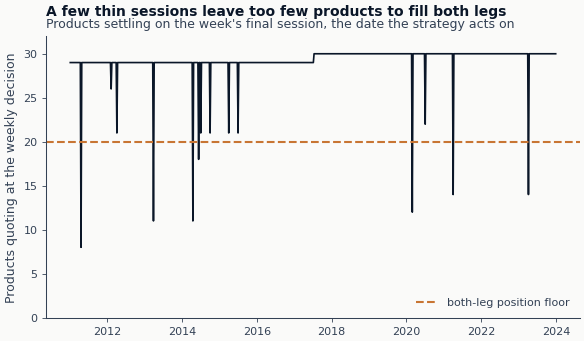

In [5]:
decisions = research.group_by(pl.col("session_date").dt.truncate("1w")).agg(
    pl.col("session_date").max().alias("decision_date")
)
breadth = (
    research.join(decisions, left_on="session_date", right_on="decision_date")
    .group_by("session_date")
    .agg(pl.col("product").n_unique().alias("n_products"))
    .sort("session_date")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["session_date"], breadth["n_products"], color=COLORS["blue"], linewidth=1.2)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="both-leg position floor")
ax.set_ylim(0, len(DECLARED_PRODUCTS) + 2)
ax.set_ylabel("Products quoting at the weekly decision")
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "A few thin sessions leave too few products to fill both legs",
    subtitle="Products settling on the week's final session, the date the strategy acts on",
)
plt.show()

### B.3 What the spread costs, and what a move is worth

`setup.yaml::costs` prices a trade as a commission plus a spread in ticks: one for most of
the universe, two for the products it lists as illiquid. The tick is a contract spec that
`futures_specs.yaml` carries - do not infer it, since the smallest settlement increment is
a half-tick on several contracts, halving the cost you charge yourself.

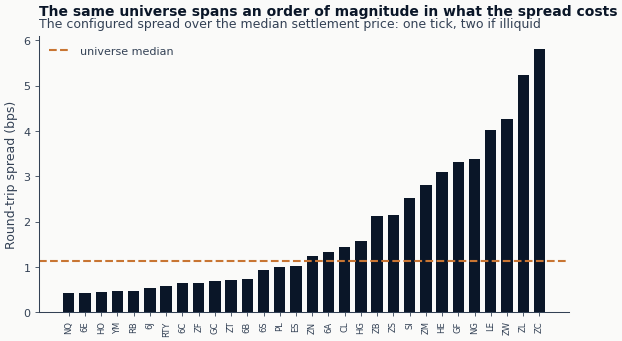

In [6]:
products = yaml.safe_load((REPO_ROOT / "data/futures/market/futures_specs.yaml").read_text())
ticks = pl.DataFrame(
    {
        "product": list(products["products"]),
        "tick": [p["tick_size"] for p in products["products"].values()],
    }
)
unticked = sorted(set(research["product"].unique().to_list()) - set(products["products"]))
assert not unticked, f"no tick size in futures_specs.yaml for: {unticked}"
illiquid, liquid = SPREAD_TICKS["illiquid"], SPREAD_TICKS["liquid"]
spread = pl.when(pl.col("product").is_in(ILLIQUID)).then(illiquid).otherwise(liquid)
cost = (
    research.group_by("product")
    .agg(pl.col("raw_close").median().alias("price"))
    .join(ticks, "product")
    .with_columns((spread * pl.col("tick") / pl.col("price") * 1e4).alias("spread_bps"))
    .sort("spread_bps")
)
COST_BPS = float(cost["spread_bps"].median())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(cost["product"], cost["spread_bps"], color=COLORS["blue"], width=0.7)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.set_ylabel("Round-trip spread (bps)")
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "The same universe spans an order of magnitude in what the spread costs",
    subtitle="The configured spread over the median settlement price: one tick, two if illiquid",
)
plt.show()

Spreads differ by an order of magnitude across the universe, so one cost line on raw
returns answers the question for no product in particular. Each move is divided by its own
product's spread instead, putting break-even at one on a shared scale.

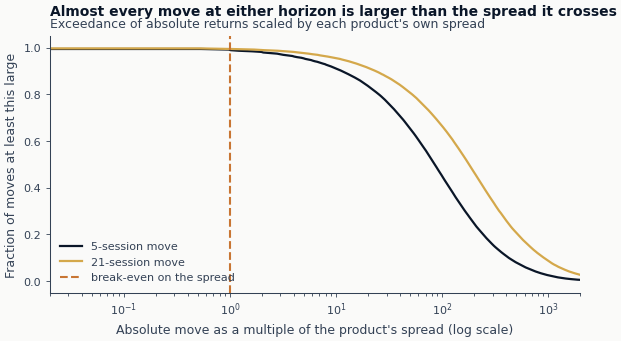

In [7]:
returns = (
    research.with_columns(
        pl.when(pl.col("adj_close").shift(h).over("product") > 0)
        .then(pl.col("adj_close").pct_change(h).abs().over("product"))
        .alias(f"h{h}")
        for h in HORIZONS
    )
    .join(cost.select("product", "spread_bps"), "product")
    .with_columns(pl.col(f"h{h}") * 1e4 / pl.col("spread_bps") for h in HORIZONS)
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"]), strict=True):
    multiple, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(1, color=COLORS["copper"], ls="--", lw=1.5, label="break-even on the spread")
ax.set_xscale("log")
ax.set_xlim(0.02, 2_000)
ax.set_xlabel("Absolute move as a multiple of the product's spread (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Almost every move at either horizon is larger than the spread it crosses",
    subtitle="Exceedance of absolute returns scaled by each product's own spread",
)
plt.show()

### B.4 How long the carrier stays put

Rebalancing weekly is only worth the turnover if what the data says at one decision date
still says something at the next. This strategy reads carry, visible in the raw prices as
the slope between the front contract and the one behind it: a positive slope means a long
position rolls into a more expensive contract and gives back part of the spot move. How
long that lasts is an autocorrelation, computed inside each product, since stacking every
product and correlating the result measures their joins instead.

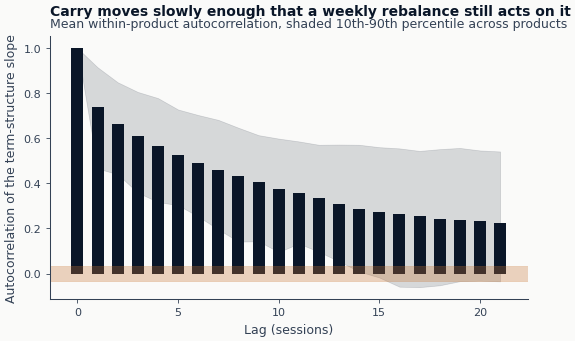

In [8]:
sealed = pl.col("session_date") < pl.lit(HOLDOUT_START).str.to_date()
term = (
    futures.filter((pl.col("tenor") <= 1) & sealed)
    .pivot(on="tenor", index=["product", "session_date"], values="raw_close")
    .rename({"0": "near", "1": "deferred"})
    .drop_nulls()
    .filter(pl.col("near") > 0)
    .sort(["product", "session_date"])
    .with_columns(((pl.col("deferred") - pl.col("near")) / pl.col("near")).alias("slope"))
)
acf = panel_acf(term, entity_col="product", value_col="slope", max_lags=max(HORIZONS))

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6)
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.3)
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("Autocorrelation of the term-structure slope")
add_message_title(
    ax,
    "Carry moves slowly enough that a weekly rebalance still acts on it",
    subtitle="Mean within-product autocorrelation, shaded 10th-90th percentile across products",
)
plt.show()

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the median spread,
and the clearance share counts moves above their own product's spread. Neither says total
cost clears.

In [9]:
multiple = pl.col(f"h{PRIMARY_HORIZON}")
median_move_bps, clears_cost = (
    returns.drop_nulls(f"h{PRIMARY_HORIZON}")
    .select(
        (multiple * pl.col("spread_bps")).median().alias("mid"),
        (multiple > 1).mean().alias("share"),
    )
    .row(0)
)
print(
    f"Round-trip spread {cost['spread_bps'].min():.2f} to "
    f"{cost['spread_bps'].max():.2f} bps, median {COST_BPS:.2f} bps | median "
    f"{PRIMARY_HORIZON}-session move {median_move_bps:.1f} bps, ratio "
    f"{median_move_bps / COST_BPS:.0f}x, over its own product's spread {clears_cost:.3f}"
)

Round-trip spread 0.43 to 5.80 bps, median 1.13 bps | median 5-session move 121.2 bps, ratio 107x, over its own product's spread 0.991


The median round-trip spread across the thirty products is 1.13 bps, from 0.43 bps on
the E-mini Nasdaq-100 to 5.80 bps on corn. The median absolute five-session move is 121.2
bps, and 0.991 of moves exceed the spread their own product would charge to cross.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` rebalances at the Friday settlement and executes at the
Monday open. B.3 supports that: moves at both horizons clear their own spread, so the
signal sets the cadence rather than cost.

### C.2 Kill conditions

Three thresholds send the strategy back to the drawing board, tested where the evidence
exists rather than here: a combined carry-and-momentum information coefficient below its
floor across folds; long-backwardation carry turning profitable over the full sample,
which would make an inverted-carry reading a regime artifact; and cost above the median
move for most of the products.

### C.3 Mapping class

`setup.yaml::mapping.class` ranks products by carry or momentum and holds both legs, and
shorting a future carries no borrow, so the short leg costs what the long leg costs.
Sizing is equal-risk: weighting by notional would let contract size decide how much each
position moves the book, when what the ranking expresses is conviction.

## D. Walk-forward structure

### D.1 Effective sample size

What evaluation spends is decision dates, not rows.

In [10]:
print(
    f"Sessions {research['session_date'].n_unique():,} | decision dates {len(decisions):,} "
    f"| products per decision {breadth['n_products'].mean():.0f}"
)

Sessions 3,357 | decision dates 678 | products per decision 29


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone. Between each
training and validation block sits a purge gap set by `labels.buffer`, stopping a label
computed inside training from resolving inside validation; the longer-horizon variant
declares its own buffer and is split under it downstream. That gap spans a few sessions
against a training block of years, so the figure below cannot resolve it and the assertion
is what establishes its width. The figure draws the boundaries the splitter returned rather
than recomputing them, so it and the folds cannot disagree.

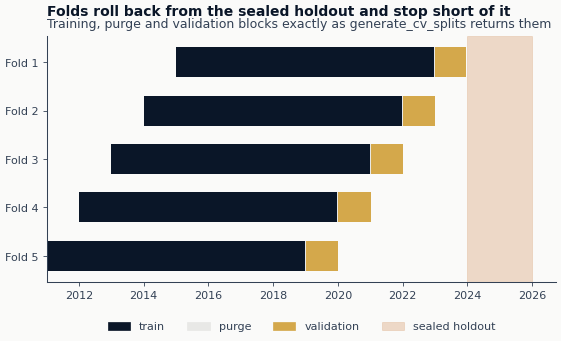

In [11]:
splits = generate_cv_splits(
    research.select("session_date").rename({"session_date": "timestamp"}),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
sessions = research["session_date"].unique().sort().to_numpy()
purge = min(int(((sessions > s["train_end"]) & (sessions < s["val_start"])).sum()) for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"
assert purge >= PRIMARY_HORIZON, "the purge gap is narrower than the primary label horizon"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "Folds roll back from the sealed holdout and stop short of it",
    subtitle="Training, purge and validation blocks exactly as generate_cv_splits returns them",
)
plt.show()

## E. Derived artifacts

Nothing is written here: the exchange listings fix the universe, so nothing downstream
reads an eligibility file from this notebook.

## F. Findings vs `setup.yaml`

One row per knob: the evidence that motivates it, and what would change it.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.n_products` | B.2 breadth per decision date | breadth falls under the position count the sweep asks for on either leg |
| `decision.cadence` | B.3 exceedance, B.4 persistence | moves stop clearing the spread, or the slope decays inside one rebalancing interval |
| `costs.spread_ticks` | B.3 tick per product from `futures_specs.yaml` | the exchange changes a tick, or a product changes liquidity class |
| `evaluation.n_splits` | D.1 decision dates, D.2 boundaries | the folds no longer fit the development window |

The count alone does not say whether `universe.n_products` needs revising, so each date the
floor binds on is listed with its weekday and whether it is Good Friday. A floor that binds
on a recurring exchange holiday, when the settlement file carries only the part of the
universe that traded, asks a different question than one that binds on arbitrary dates. The
same applies to the step in breadth: it is dated by the last product to list rather than
read off the chart.

In [12]:
listings = (
    research.group_by("product").agg(pl.col("session_date").min().alias("listed")).sort("listed")
)
newest = listings.row(-1, named=True)
modal_before = breadth.filter(pl.col("session_date") < newest["listed"])["n_products"].mode().max()
modal_after = breadth.filter(pl.col("session_date") >= newest["listed"])["n_products"].mode().max()

thin = breadth.filter(pl.col("n_products") < BREADTH_FLOOR).sort("session_date")
good_friday = set(
    GoodFriday.dates(str(breadth["session_date"].min()), str(breadth["session_date"].max())).date
)
thin_lines = "\n".join(
    f"  {d} {d:%a} breadth {n:>2} " + ("Good Friday" if d in good_friday else "regular session")
    for d, n in zip(thin["session_date"], thin["n_products"], strict=True)
)

print(
    f"universe.n_products {SETUP['universe']['n_products']}, breadth per decision date "
    f"{breadth['n_products'].min()} to {breadth['n_products'].max()}, modal {modal_before} "
    f"before {newest['product']} first settles {newest['listed']} and {modal_after} after\n"
    f"under the floor of {BREADTH_FLOOR} on {thin.height} of {len(breadth)} decision dates, "
    f"{sum(d in good_friday for d in thin['session_date'])} of them Good Friday:\n"
    f"{thin_lines}\n"
    f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched\n"
    f"labels.buffer {LABEL_BUFFER}, narrowest purge {purge} sessions against the "
    f"{PRIMARY_HORIZON}-session primary horizon"
)

universe.n_products 30, breadth per decision date 8 to 30, modal 29 before RTY first settles 2017-07-10 and 30 after
under the floor of 20 on 7 of 678 decision dates, 5 of them Good Friday:
  2011-04-22 Fri breadth  8 Good Friday
  2013-03-29 Fri breadth 11 Good Friday
  2014-04-18 Fri breadth 11 Good Friday
  2014-06-13 Fri breadth 18 regular session
  2020-02-28 Fri breadth 12 regular session
  2021-04-02 Fri breadth 14 Good Friday
  2023-04-07 Fri breadth 14 Good Friday
decision.cadence weekly_friday_close | labels.primary fwd_ret_5d
evaluation.n_splits 5, generated 5, last validation ends 2023-12-21, holdout untouched
labels.buffer 5D, narrowest purge 5 sessions against the 5-session primary horizon


Breadth is 29 products until the small-cap index contract (RTY) first settles on
2017-07-10 and 30 after, with 8 at its worst on a Good Friday; the floor of 20 binds on 7
of 678 decision dates, five of them Good Friday and two regular Fridays on which the
settlement file carries part of the universe. Five folds are generated, the last validation
ending 2023-12-21, and the narrowest gap between a training block and the validation window
that follows it is 5 sessions, the horizon of the primary label.

## Key takeaways

1. **Count the universe on the session the strategy acts on.** Anywhere-in-the-week hides
   the thin sessions where a two-sided book cannot be filled.
2. **Take the tick from the contract specification, not from the prices.** Several
   contracts settle on half-ticks, so the observed grid understates what you pay.
3. **Scale moves by each product's own spread before comparing them to cost**, and
   compute a panel autocorrelation inside each entity, never across the stack.
4. **Guard every denominator.** A back-adjusted series can cross zero once the accumulated
   roll adjustment outgrows the price, and a change measured off a non-positive base is not
   a return.

### Known limitations

- Cost here is the spread alone; commission and roll slippage need a notional and enter at
  the cost stage, which also tests whether a persistent carry reading is profitable.

**Next**: labels at the declared horizons, built on this development window.